Mapping green spaces and calculating their area by neighbourhood

This is my first attempt at using the GeoPandas library! It is just a simple project looking at where green spaces are located in Exeter, UK.

The dataset used for this project is "Wards (May 2025) Boundaries UK BFC (V2)", which can be found here: https://www.data.gov.uk/dataset/612b175b-987c-4acf-8ca4-1f93c6947928/wards-may-2025-boundaries-uk-bfc-v2.

In [1]:
# importing relevant libraries
import io
import textwrap

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import osmnx as ox
import pandas as pd
import requests

In [2]:
# load ward boundaries from the ArcGIS FeatureServer as GeoJSON (Exeter only), with local fallback
url = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/ArcGIS/rest/services/"
    "WD_MAY_2025_UK_BFC_V2/FeatureServer/0/query?"
    "where=LAD25NM%3D%27Exeter%27&outFields=*&outSR=4326&f=geojson"
)
try:
    neighbourhoods = gpd.read_file(url)
    print("Loaded Exeter wards from ArcGIS FeatureServer.")
except Exception as e:
    print(f"Could not load from service: {e}. Falling back to local GeoPackage.")
    try:
        neighbourhoods = gpd.read_file("WD_MAY_2025_UK_BFC_V2_-5185687143062460842.gpkg")
        print("Loaded local GeoPackage.")
    except FileNotFoundError as e:
        print(f"Local file not found: {e}")

Loaded Exeter wards from ArcGIS FeatureServer.


In [3]:
# downloading the green spaces in Exeter using OSMnx, and loading this into a GeoDataFrame called 'green'
# selecting the features that match the tags for leisure parks, gardens, and landuse grass, which are common indicators of green spaces in OpenStreetMap data
green = ox.features_from_place(
    "Exeter, UK",
    tags={"leisure": ["park", "garden"], "landuse": "grass"}
)

In [4]:
# reprojecting both GeoDataFrames to the same coordinate reference system (CRS) to ensure accurate spatial analysis
neighbourhoods = neighbourhoods.to_crs(3857)
green = green.to_crs(3857)
green = green[green.geometry.notnull()]

In [5]:
# clip green spaces to ward boundaries so that shared green polygons are not counted more than once
joined = gpd.overlay(green, neighbourhoods, how="intersection")
joined["area_m2"] = joined.geometry.area

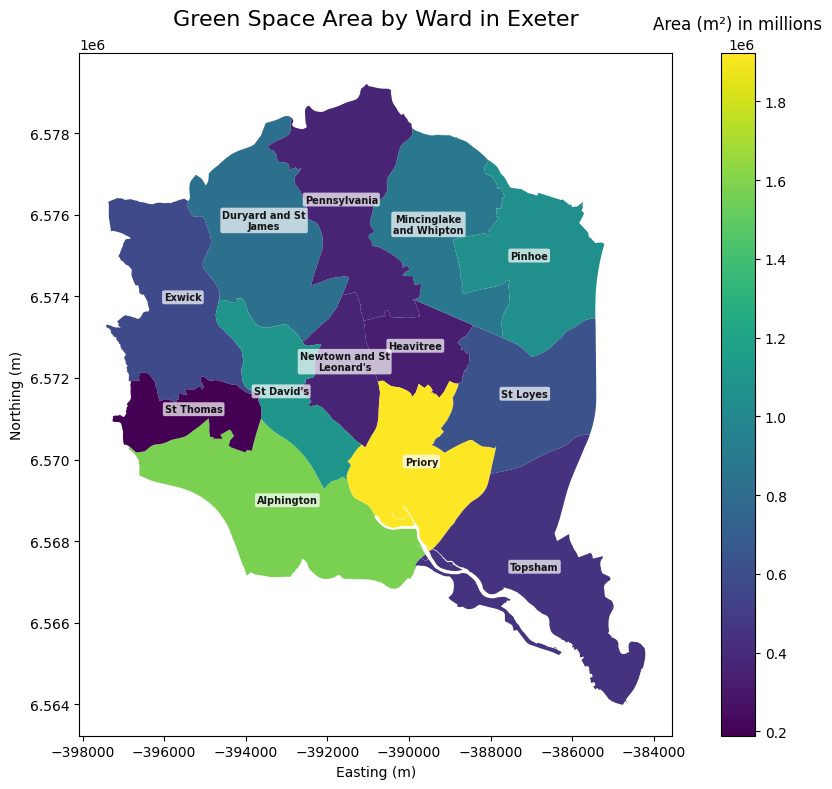

In [6]:
# grouping by the correct ward name column
summary = joined.groupby("WD25NM")["area_m2"].sum().reset_index()

# merging back into the neighbourhoods GeoDataFrame
neighbourhoods = neighbourhoods.merge(summary, on="WD25NM", how="left")

# if merge created a suffixed version of the column, keep the joined values
if "area_m2" not in neighbourhoods.columns:
    if "area_m2_y" in neighbourhoods.columns:
        neighbourhoods["area_m2"] = neighbourhoods["area_m2_y"]
    elif "area_m2_x" in neighbourhoods.columns:
        neighbourhoods["area_m2"] = neighbourhoods["area_m2_x"]

# filtering to Exeter only (otherwise you plot the whole UK)
exeter = neighbourhoods[neighbourhoods["LAD25NM"] == "Exeter"]

# plotting the area of green spaces in each ward in Exeter using a choropleth map
ax = exeter.plot(
    column="area_m2",
    cmap="viridis",
    legend=True,
    figsize=(10, 8)
)

# add ward labels at the representative point of each polygon
for _, row in exeter.iterrows():
    point = row.geometry.representative_point()
    label = "\n".join(textwrap.wrap(row["WD25NM"], width=14))
    ax.annotate(
        text=label,
        xy=(point.x, point.y),
        horizontalalignment="center",
        fontsize=7,
        color="black",
        weight="bold",
        alpha=0.9,
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "boxstyle": "round,pad=0.2"},
        zorder=5,
    )

ax.set_title("Green Space Area by Ward in Exeter", fontsize=16, pad=20)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

# accessing the colorbar (GeoPandas legend)
fig = ax.get_figure()
fig.tight_layout()
cax = fig.axes[-1] if len(fig.axes) > 1 else None
if cax is not None:
    cax.set_title("Area (m²) in millions")

Interpreting the graph:

What the colours mean:
- Each ward (polygon) is coloured based on how much green space exists inside it, measured in square meters.
- dark purple: very little green space
- blue/green: moderate green space
- yellow: a lot of green space
- The colour is a direct visual encoding of the total area of parks, gardens, and grassland in that ward.

What the 'areas' are:
- Each of the polygons represents a ward (administrative neighbourhood) from the official ONS dataset.
- The colour of that polygon tells you how green it is (in absolute area, not percentage).

You might be thinking... some wards are larger than others, or have a bigger population. Just focusing on the area of the green space in each isn't actually telling us that much.

So, next, I'm going to examine green space per square metre of ward.

In [7]:
# calculating how green the ward is relative to its size by calculating the percentage of the ward area that is green space
exeter["ward_area_m2"] = exeter.geometry.area
exeter["pct_green"] = (exeter["area_m2"] / exeter["ward_area_m2"]) * 100

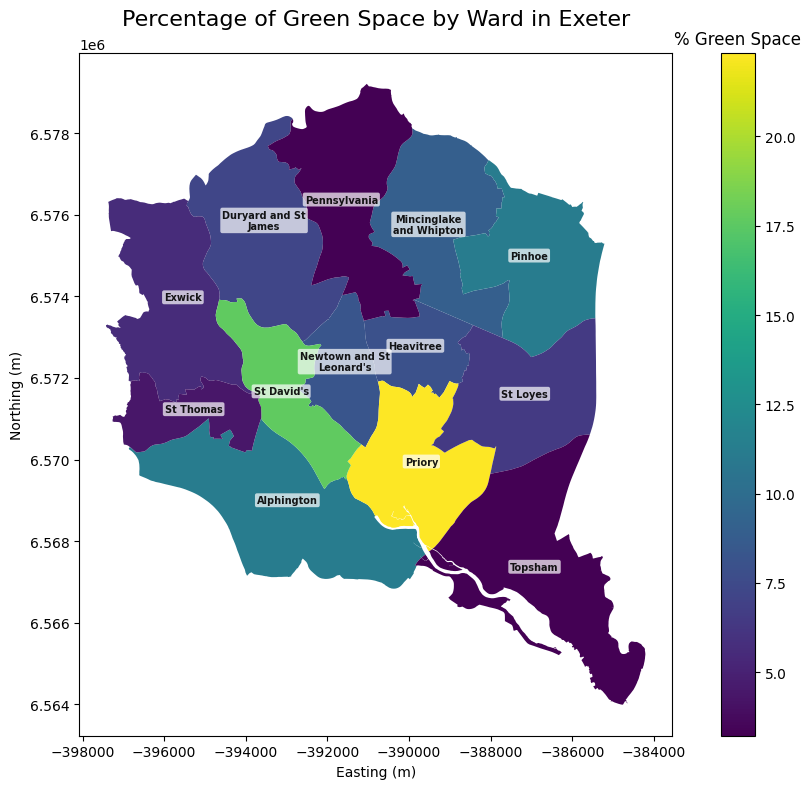

In [8]:
# plotting graph with ward labels
ax = exeter.plot(
    column="pct_green",
    cmap="viridis",
    legend=True,
    figsize=(10, 8)
)

# add ward labels at the representative point of each polygon
for _, row in exeter.iterrows():
    point = row.geometry.representative_point()
    label = "\n".join(textwrap.wrap(row["WD25NM"], width=14))
    ax.annotate(
        text=label,
        xy=(point.x, point.y),
        horizontalalignment="center",
        fontsize=7,
        color="black",
        weight="bold",
        alpha=0.9,
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "boxstyle": "round,pad=0.2"},
        zorder=5,
    )

ax.set_title("Percentage of Green Space by Ward in Exeter", fontsize=16, pad=20)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
fig = ax.get_figure()
fig.tight_layout()
cax = fig.axes[-1] if len(fig.axes) > 1 else None
if cax is not None:
    cax.set_title("% Green Space")

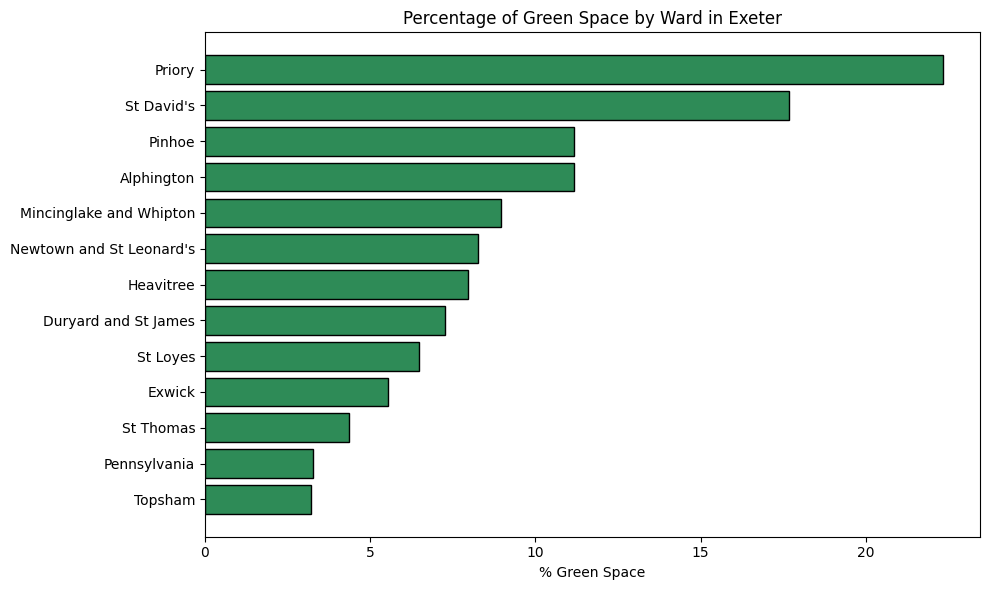

In [9]:
# A bar chart for easier comparison of percentage green space by ward
bar_df = exeter.sort_values("pct_green", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(bar_df["WD25NM"], bar_df["pct_green"], color="seagreen", edgecolor="black")
ax.set_xlabel("% Green Space")
ax.set_title("Percentage of Green Space by Ward in Exeter")
ax.invert_yaxis()
plt.tight_layout()

Next, I analysed green space per capita: "How much green space does each person effectively have?"

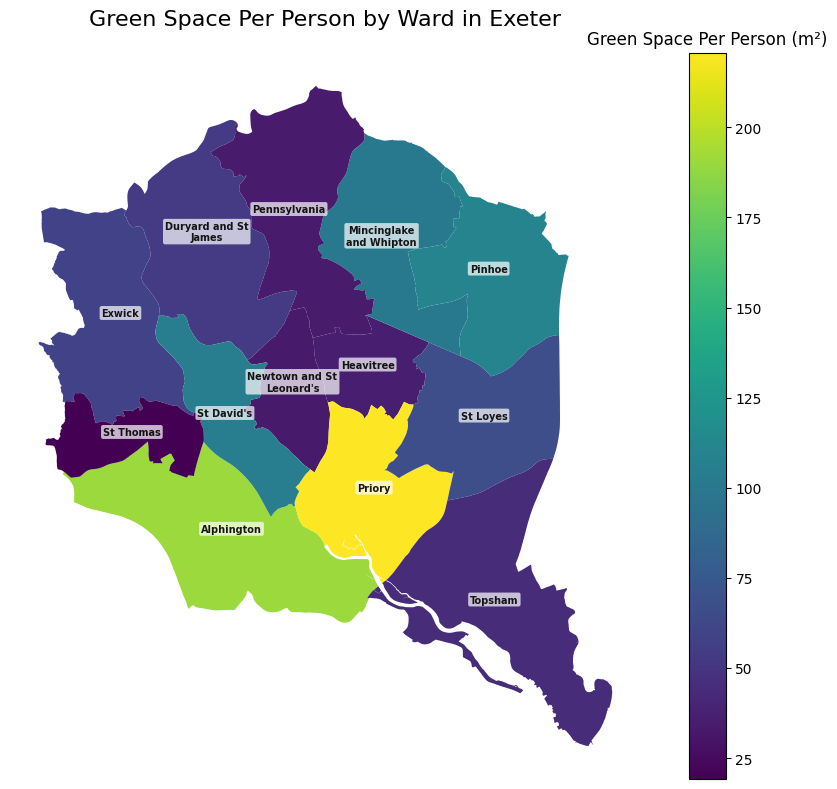

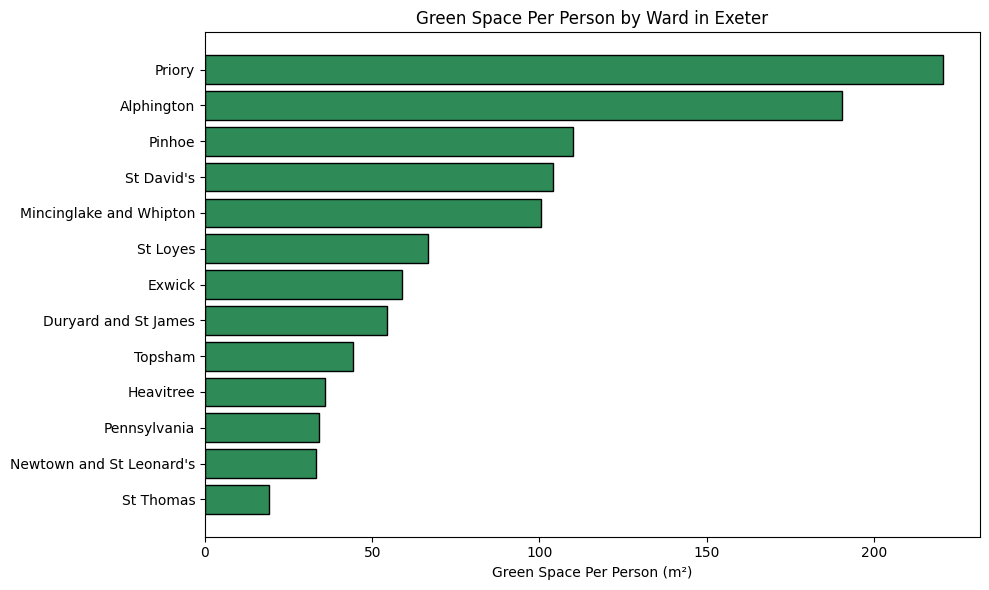

In [10]:
URL = "https://www.nomisweb.co.uk/api/v01/dataset/NM_2021_1.data.csv"
params = {
    "geography": "E07000041TYPE153",  # Exeter wards (2022 ward geography)
    "time": "2021",
    "c2021_restype_3": "0",  # Total: All usual residents
    "measures": "20100",  # Persons Value
    "select": "geography_name,obs_value",
    "recordlimit": "50",
}

r = requests.get(URL, params=params)
r.raise_for_status()

df = pd.read_csv(io.StringIO(r.text))
df.columns = df.columns.str.lower()
df = df.rename(columns={"geography_name": "ward_name", "obs_value": "population"})

df["ward_name"] = df["ward_name"].str.replace(r" \(Exeter\)$", "", regex=True)
df = df.sort_values("ward_name")

# merge onto exeter GeoDataFrame using the ward name column
exeter = exeter.merge(df, left_on="WD25NM", right_on="ward_name", how="left")

missing = exeter[exeter["population"].isna()]
if not missing.empty:
    print("Missing population for wards:", missing["WD25NM"].tolist())

# calculate green space per capita
exeter["green_per_person"] = exeter["area_m2"] / exeter["population"]

# plotting
ax = exeter.plot(
    column="green_per_person",
    cmap="viridis",
    legend=True,
    figsize=(10, 8),
)


# add ward labels at the representative point of each polygon
for _, row in exeter.iterrows():
    point = row.geometry.representative_point()
    label = "\n".join(textwrap.wrap(row["WD25NM"], width=14))
    ax.annotate(
        text=label,
        xy=(point.x, point.y),
        horizontalalignment="center",
        fontsize=7,
        color="black",
        weight="bold",
        alpha=0.9,
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none", "boxstyle": "round,pad=0.2"},
        zorder=5,
    )

ax.set_title("Green Space Per Person by Ward in Exeter", fontsize=16, pad=20)
ax.set_axis_off()

fig = ax.get_figure()
fig.tight_layout()
cax = fig.axes[-1] if len(fig.axes) > 1 else None
if cax is not None:
    cax.set_title("Green Space Per Person (m²)")
plt.show()

# A bar chart for easier comparison of green space per person per ward
bar_df = exeter.sort_values("green_per_person", ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(bar_df["WD25NM"], bar_df["green_per_person"], color="seagreen", edgecolor="black")
ax.set_xlabel("Green Space Per Person (m²)")
ax.set_title("Green Space Per Person by Ward in Exeter")
ax.invert_yaxis()
plt.tight_layout()

## Green Space Density Heatmap

This heatmap shows the concentration and clustering of green spaces across Exeter, rather than just total area by ward. Areas with warmer colors (yellow/red) indicate higher density of green space features.

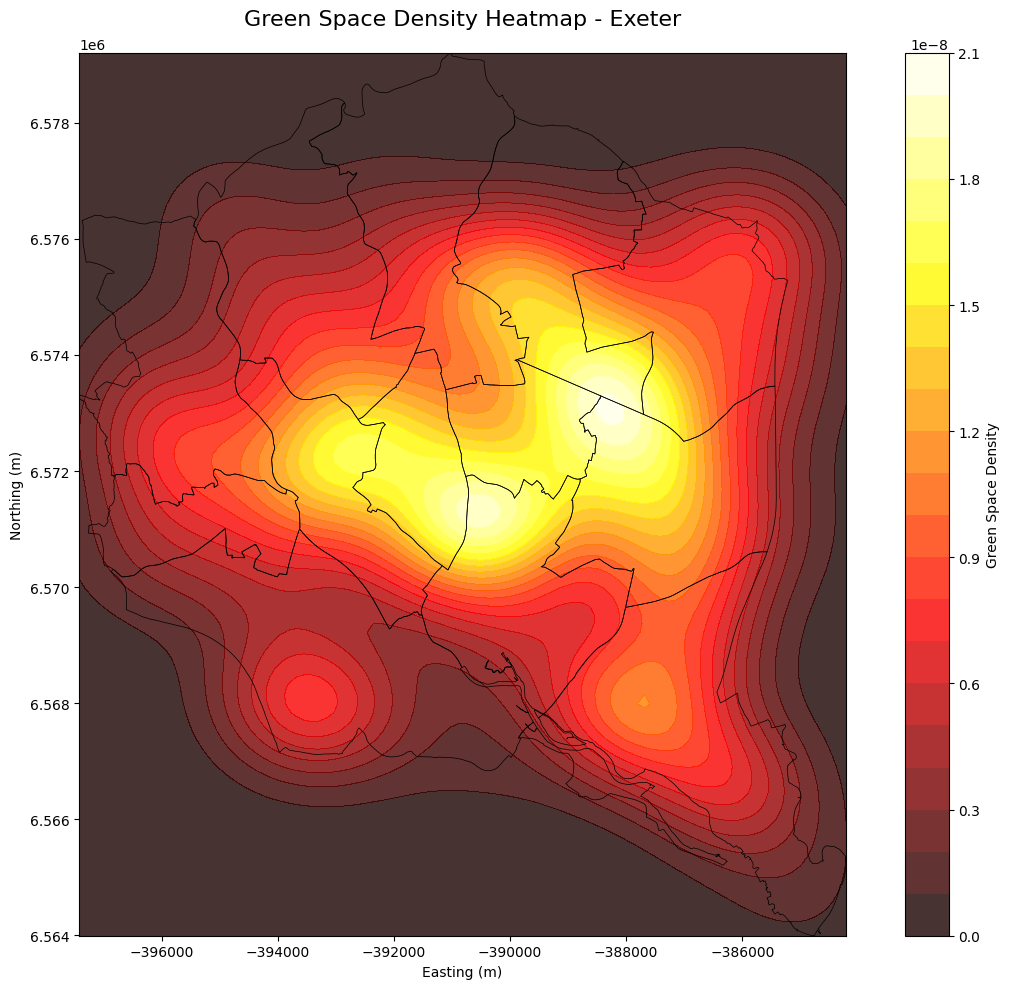

In [11]:
import numpy as np
from scipy.stats import gaussian_kde

# extract green space centroids and convert to Web Mercator for density calculation
green_centroids = green.copy()
green_centroids['geometry'] = green_centroids.geometry.centroid

# get x, y coordinates
x = np.array([geom.x for geom in green_centroids.geometry])
y = np.array([geom.y for geom in green_centroids.geometry])

# create a grid covering Exeter
minx, miny, maxx, maxy = exeter.total_bounds
grid_size = 100
grid_x = np.linspace(minx, maxx, grid_size)
grid_y = np.linspace(miny, maxy, grid_size)
xx, yy = np.meshgrid(grid_x, grid_y)

# reshape grid for KDE evaluation
positions = np.vstack([xx.ravel(), yy.ravel()])
kernel = gaussian_kde(np.vstack([x, y]))
density = kernel(positions).reshape(xx.shape)

# plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))
heatmap = ax.contourf(xx, yy, density, levels=20, cmap='hot', alpha=0.8)
exeter.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5)

plt.colorbar(heatmap, ax=ax, label='Green Space Density')
ax.set_title('Green Space Density Heatmap - Exeter', fontsize=16, pad=20)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
fig.tight_layout()
plt.show()

## Interactive Heatmap

Use the interactive map below to explore green space concentration. You can zoom and pan to see fine-grained clustering patterns.

In [12]:
import folium
from folium.plugins import HeatMap

# reproject green centroids to WGS84 (latitude/longitude) for Folium
green_wgs84 = green_centroids.to_crs(4326)

# extract lat/lon pairs
heat_data = [[geom.y, geom.x] for geom in green_wgs84.geometry]

# create base map centered on Exeter
exeter_center = [50.7184, -3.5339]  # approximate center of Exeter
m = folium.Map(location=exeter_center, zoom_start=12, tiles='OpenStreetMap')

# add heatmap layer
HeatMap(heat_data, radius=25, blur=15, max_zoom=1).add_to(m)

# add ward boundaries as a reference
for _, row in exeter.to_crs(4326).iterrows():
    folium.GeoJson(
        data=row.geometry.__geo_interface__,
        style_function=lambda x: {'color': 'black', 'fillOpacity': 0.0, 'weight': 1}
    ).add_to(m)

m